
Dokumentacja:
utworzenie modelu, konfiguracja uczenia, opis augmentacji, dlaczego augmentacja lepsza, analiza wyjasnialnosci, opis pipeline yolo -> mobilenetv3, 

## Mobilenet v3 kod treningwey
Best model at Epoch 12- Train Loss: 0.5485 | Val Loss: 0.7457 | Acc: 0.9220 | F1: 0.9219 | CO₂: 0.033600 kg
0.572058 kWh 0.05 g.CO2eq/s mean an estimation of 1507 kg.CO2eq/year
https://www.epa.gov/energy/greenhouse-gas-equivalencies-calculator#results

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import f1_score
import wandb
from codecarbon import EmissionsTracker


wandb.init(project="CatBreedClassifierv2", config={
    "epochs": 50,
    "batch_size": 64,
    "learning_rate": 0.0005,
    "weight_decay": 1e-4,
    "optimizer": "AdamW",
    "architecture": "MobileNetV3-FineTuning7Blocks"
})

config = wandb.config
tracker = EmissionsTracker(output_dir="carbon_logs", measure_power_secs=10)
tracker.start()

train_transform = A.Compose([
    A.RandomResizedCrop(
        size=(224, 224),
        scale=(0.6, 1.0),
        ratio=(0.75, 1.333),
        p=1.0
    ),
    A.HorizontalFlip(p=0.5),

    A.Affine(
        translate_percent=0.1,
        scale=(0.75, 1.25),
        rotate=(-30, 30),
        mode=0,
        p=0.6
    ),

    A.MotionBlur(blur_limit=7, p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),

    A.RandomBrightnessContrast(p=0.3),

    A.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05,
        p=0.3
    ),
    
    A.GaussNoise(std_range=(0.01, 0.05), p=0.3),

    A.CoarseDropout(
        num_holes_range=(1, 4),
        hole_height_range=(16, 32),
        hole_width_range=(16, 32),
        fill=0,
        p=0.3
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2(),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

data_dir = 'data'
dataset = datasets.ImageFolder(data_dir)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_data, test_data = random_split(dataset, [train_size, test_size])

train_data.dataset.transform = train_transform
test_data.dataset.transform = test_transform

train_loader = DataLoader(train_data, batch_size=config.batch_size, num_workers=4, shuffle=True)
test_loader = DataLoader(test_data, batch_size=config.batch_size, shuffle=False)
num_classes = len(dataset.classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.mobilenet_v3_large(
    weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
)

for param in model.features.parameters():
    param.requires_grad = False

for layer in model.features[-7:]:
    for param in layer.parameters():
        param.requires_grad = True

in_features = model.classifier[3].in_features

model.classifier = nn.Sequential(
    model.classifier[0],
    model.classifier[1],
    nn.Dropout(0.3),
    nn.Linear(in_features, num_classes)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=config.learning_rate,
                        weight_decay=config.weight_decay)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.2,      
    patience=3,     
    verbose=True,
    min_lr=1e-6
)


best_val_loss = float('inf')

# TRENING
for epoch in range(config.epochs):
    model.train()
    running_loss = 0.0
    total_steps = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        total_steps += 1

    avg_train_loss = running_loss / total_steps

    # WALIDACJA 
    model.eval()
    val_loss, correct, total = 0.0, 0, 0
    all_labels, all_preds = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    avg_val_loss = val_loss / len(test_loader)
    val_accuracy = correct / total
    val_f1 = f1_score(all_labels, all_preds, average='weighted')

    scheduler.step(avg_val_loss)

    emissions = tracker._prepare_emissions_data()
    emissions_kg = emissions.emissions if emissions else 0.0

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'mobilenetv3_finetuned.pth')

    
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": avg_train_loss,
        "train/learning_rate": scheduler.get_last_lr()[0],
        "eval/loss": avg_val_loss,
        "eval/accuracy": val_accuracy,
        "eval/f1": val_f1,
        "carbon/emissions_kg": emissions_kg
    })

    print(f"Epoch {epoch+1}/{config.epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Acc: {val_accuracy:.4f} | "
          f"F1: {val_f1:.4f} | "
          f"CO₂: {emissions_kg:.6f} kg")


tracker.stop()
wandb.finish()


## Pred na zdjęciu

/tmp/ipykernel_2447559/175168755.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=device))



IMAGE: smol.jpeg


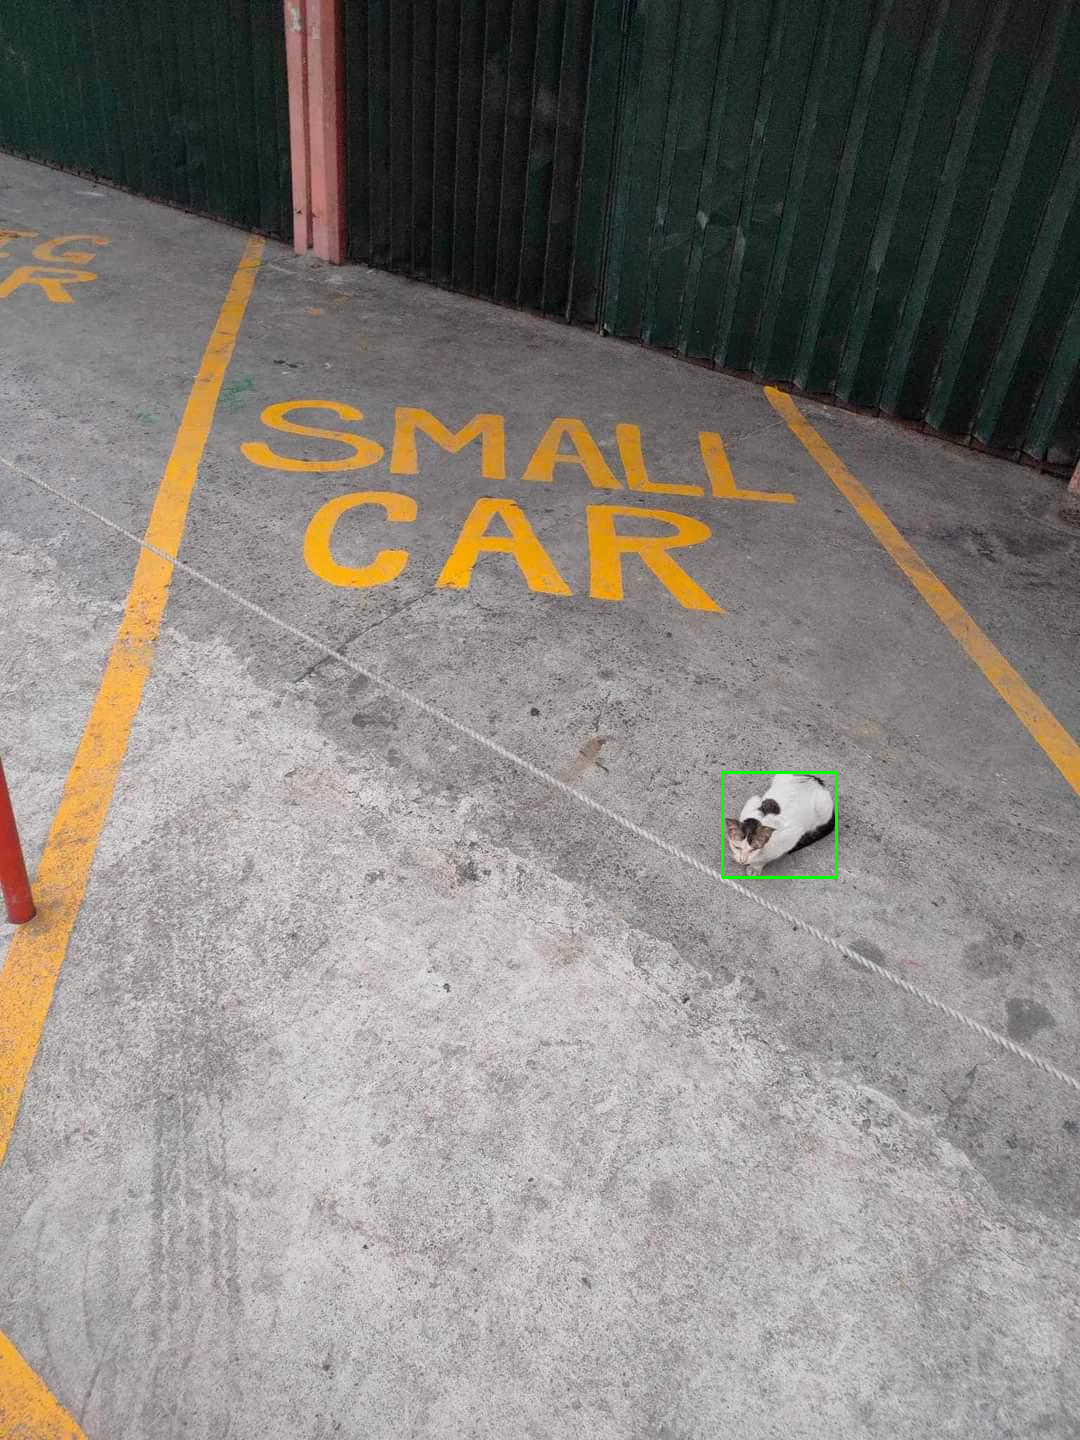

Abyssinian: 0.59
Sphynx: 0.07
Bengal: 0.06

IMAGE: car.jpg


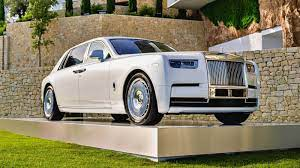

Not cat: 0.86
Sphynx: 0.02
Egyptian Mau: 0.01

IMAGE: doggo.jpg


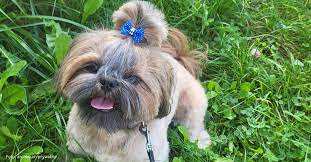

Not cat: 0.68
Birman: 0.08
Siamese: 0.05

IMAGE: desk.jpg


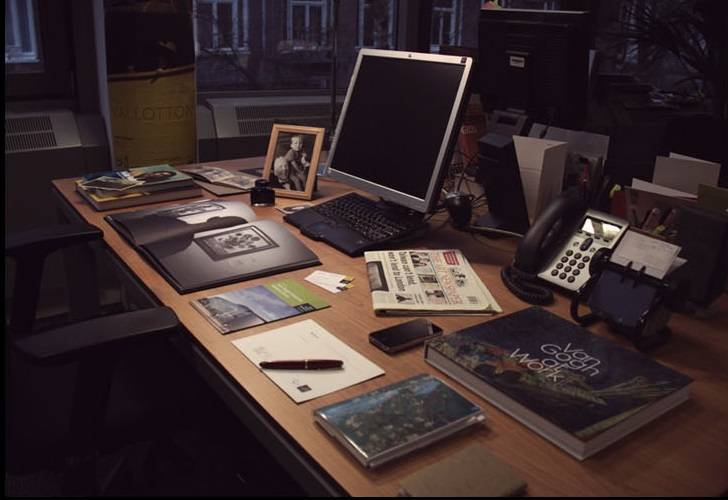

Not cat: 0.51
British Shorthair: 0.07
Egyptian Mau: 0.06


In [1]:
import torch
import cv2
import numpy as np
from torchvision import datasets, transforms, models
from PIL import Image
from IPython.display import Image as IPImage, display
from ultralytics import YOLO

MODEL_PATH = "mobilenetv3_finetuned.pth"
DATA_DIR = "data"
YOLO_WEIGHTS = "yolo11s.pt"   
CONF_DET = 0.4    #próg pewności dla YOLO          
CLASS_CAT = 15               
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = datasets.ImageFolder(DATA_DIR)
class_names = dataset.classes
num_classes = len(class_names)

def load_model(model_path):
    model = models.mobilenet_v3_large(weights=None)

    in_features = model.classifier[3].in_features
    model.classifier = torch.nn.Sequential(
        model.classifier[0],
        model.classifier[1],
        torch.nn.Dropout(0.3),
        torch.nn.Linear(in_features, num_classes)
    )
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model

model = load_model(MODEL_PATH)
yolo = YOLO(YOLO_WEIGHTS)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def detect_cat_crop(pil_img):
    img_np = np.array(pil_img)
    results = yolo(img_np, conf=CONF_DET, verbose=False)[0]

    if results.boxes is None:
        return pil_img, None

    cat_boxes = []
    for box, cls in zip(results.boxes.xyxy, results.boxes.cls):
        if int(cls.item()) == CLASS_CAT:
            cat_boxes.append(box.cpu().numpy())

    if len(cat_boxes) == 0:
        return pil_img, None

    x1, y1, x2, y2 = max(
        cat_boxes, key=lambda b: (b[2]-b[0])*(b[3]-b[1])
    )

    h, w, _ = img_np.shape
    x1, y1 = max(0, int(x1)), max(0, int(y1))
    x2, y2 = min(w, int(x2)), min(h, int(y2))

    crop = img_np[y1:y2, x1:x2]
    return Image.fromarray(crop), (x1, y1, x2, y2)

def predict_image(image_path):
    pil = Image.open(image_path).convert("RGB")

    crop, bbox = detect_cat_crop(pil)

    tensor = transform(crop).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1)[0]

    top3_prob, top3_idx = torch.topk(probs, 3)
    results = [(class_names[i], p.item()) for i, p in zip(top3_idx, top3_prob)]

    img_vis = np.array(pil)
    if bbox is not None:
        x1, y1, x2, y2 = bbox
        cv2.rectangle(img_vis, (x1,y1), (x2,y2), (0,255,0), 2)

    display(Image.fromarray(img_vis))

    return results

for img in ["smol.jpeg", "car.jpg", "doggo.jpg", "desk.jpg"]:
    print(f"\nIMAGE: {img}")
    preds = predict_image(img)

    for cls, p in preds:
        print(f"{cls}: {p:.2f}")


## YOLO v11 SMALL

In [2]:
import cv2
import torch
import numpy as np
from torchvision import models, datasets, transforms
from collections import deque, Counter
from PIL import Image
from ultralytics import YOLO

VIDEO_PATH = "IMG_7879.mp4"
OUTPUT_PATH = "output_pred_yolo11s.mp4"
MODEL_PATH = "mobilenetv3_finetuned.pth"
DATA_DIR = "data"

WINDOW_SIZE = 15
CONF_THRESHOLD = 0.3
YOLO_CONF = 0.25
CAT_CLASS_ID = 15  # klasa cat z COCO 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = datasets.ImageFolder(DATA_DIR)
class_names = dataset.classes
num_classes = len(class_names)

def load_model(path):
    model = models.mobilenet_v3_large(weights=None)

    in_features = model.classifier[3].in_features
    model.classifier = torch.nn.Sequential(
        model.classifier[0],
        model.classifier[1],
        torch.nn.Dropout(0.3),
        torch.nn.Linear(in_features, num_classes)
    )

    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device).eval()
    return model

model = load_model(MODEL_PATH)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# smoothing zeby nie skakalo
pred_queue = deque(maxlen=WINDOW_SIZE)

def smooth_prediction(preds):
    return Counter(preds).most_common(1)[0][0]

def center_crop(img):
    h, w, _ = img.shape
    s = min(h, w)
    y = (h - s) // 2
    x = (w - s) // 2
    return img[y:y+s, x:x+s]

#DETEKCJA
yolo = YOLO("yolo11s.pt")       
yolo.to(device)            

def detect_cat_crop(frame_rgb):
    results = yolo(
        frame_rgb,
        conf=YOLO_CONF,
        classes=[CAT_CLASS_ID],  
        verbose=False
    )[0]

    if results.boxes is None or len(results.boxes) == 0:
        return center_crop(frame_rgb), None

    boxes = results.boxes.xyxy.cpu().numpy()

    x1, y1, x2, y2 = max(
        boxes,
        key=lambda b: (b[2] - b[0]) * (b[3] - b[1])
    )

    h, w, _ = frame_rgb.shape
    x1, y1 = int(max(0, x1)), int(max(0, y1))
    x2, y2 = int(min(w, x2)), int(min(h, y2))

    return frame_rgb[y1:y2, x1:x2], (x1, y1, x2, y2)

# VIDEO - PREDYKCJA
cap = cv2.VideoCapture(VIDEO_PATH)
assert cap.isOpened(), "Nie można otworzyć wideo"

fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter(
    OUTPUT_PATH,
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    crop, bbox = detect_cat_crop(frame_rgb)
    pil_img = Image.fromarray(crop)

    img = transform(pil_img).unsqueeze(0).to(device)

    with torch.no_grad():
        probs = torch.softmax(model(img), dim=1)[0]
        conf, pred_idx = torch.max(probs, dim=0)

    label = (
        class_names[pred_idx.item()]
        if conf.item() >= CONF_THRESHOLD
        else "Unknown"
    )

    pred_queue.append(label)
    stable_label = smooth_prediction(pred_queue)

    if bbox:
        cv2.rectangle(frame, bbox[:2], bbox[2:], (0, 255, 0), 2)

    text = f"{stable_label} ({conf.item():.2f})"
    cv2.rectangle(frame, (10, 10), (520, 60), (0, 0, 0), -1)
    cv2.putText(
        frame, text, (20, 50),
        cv2.FONT_HERSHEY_SIMPLEX, 1.2,
        (0, 255, 0), 2
    )

    out.write(frame)

cap.release()
out.release()
print("Zapisano:", OUTPUT_PATH)


/tmp/ipykernel_2447559/643635523.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=device))


Zapisano: output_pred_yolo11s.mp4
